In [1]:
# ===== Imports =====
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import random
from sklearn.metrics import roc_curve, auc
from torch.utils.data import DataLoader, Subset

In [2]:
import mplhep as mh
mh.style.use("CMS")
USE_CMS_STYLE = True

In [24]:
# ===== ME0SegReco Setup =====
import sys
import site
user_site = site.USER_SITE
me0_src = '/eos/home-i01/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/src'
for path in [user_site, me0_src]:
    if path not in sys.path:
        sys.path.insert(0, path)
        
from me0.data.datasets.GNNDataset import GNNDataset
from me0.modules.gnn.model import HitGNN
print("✓ ME0SegReco loaded")

✓ ME0SegReco loaded


In [4]:
# ===== Reproducibility =====
def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [5]:
# ===== Device Setup =====
device = torch.device('cuda' if torch.cuda.is_available() else 
                     'mps' if torch.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [6]:
# ============================================================================
# CELL 6: Load Dataset - Correct Way
# ============================================================================
import os

print("\nLoading GNN dataset...")
print("="*70)

# The root should be a directory, not the HDF5 file!
data_dir = "/eos/user/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/data"
hdf5_file = os.path.join(data_dir, "merged_step4_rechit.h5")

# Verify file exists
if not os.path.exists(hdf5_file):
    print(f"❌ HDF5 file not found: {hdf5_file}")
    raise FileNotFoundError(f"Cannot find {hdf5_file}")

print(f"📂 Data directory: {data_dir}")
print(f"📦 HDF5 file: {hdf5_file}")
print(f"   File size: {os.path.getsize(hdf5_file) / (1024**3):.2f} GB")

try:
    # Pass the DIRECTORY as root, not the file!
    dataset = GNNDataset(
        root=data_dir,  # <-- Directory, not file!
        d_strip_max=10,
        d_ieta_max=2,
        d_bx_max=1
    )
    print(f"\n✓ Dataset loaded successfully!")
    print(f"✓ Total events: {len(dataset):,}")
    
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print(f"\nDebugging info:")
    print(f"  Directory exists: {os.path.isdir(data_dir)}")
    print(f"  HDF5 file exists: {os.path.isfile(hdf5_file)}")
    print(f"  Directory writable: {os.access(data_dir, os.W_OK)}")
    raise


Loading GNN dataset...
📂 Data directory: /eos/user/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/data
📦 HDF5 file: /eos/user/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/data/merged_step4_rechit.h5
   File size: 0.61 GB

✓ Dataset loaded successfully!
✓ Total events: 35,430


In [7]:
# ===== Dataset Split (70/15/15) =====
total_size = len(dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print(f"\nDataset split (70/15/15):")
print(f"  Total: {total_size:,}")
print(f"  Train: {train_size:,} (70%)")
print(f"  Val:   {val_size:,} (15%)")
print(f"  Test:  {test_size:,} (15%)")


Dataset split (70/15/15):
  Total: 35,430
  Train: 24,801 (70%)
  Val:   5,314 (15%)
  Test:  5,315 (15%)


In [8]:
# Create subsets
train_indices = list(range(0, train_size))
val_indices = list(range(train_size, train_size + val_size))
test_indices = list(range(train_size + val_size, total_size))

train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)
test_subset = Subset(dataset, test_indices)

In [9]:
# Create data loaders
batch_size = 128
from torch_geometric.loader import DataLoader

# Don't specify collate_fn for PyTorch Geometric DataLoader
train_loader = DataLoader(train_subset, shuffle=True, drop_last=True, batch_size=batch_size)
val_loader = DataLoader(val_subset, shuffle=False, drop_last=True, batch_size=batch_size)
test_loader = DataLoader(test_subset, shuffle=False, drop_last=True, batch_size=batch_size)

print(f"\n✓ Data loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


✓ Data loaders created:
  Train batches: 193
  Val batches:   41
  Test batches:  41


In [10]:
# ===== Model Parameter Count Function =====
def count_parameters(model):
    """Count total and trainable parameters in model"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [11]:
# ===== PHASE 1: Learning Rate Sweep =====
print("\n" + "="*70)
print("PHASE 1: Learning Rate Sweep")
print("="*70)

def run_lr_sweep(learning_rates, num_epochs=10):
    """
    Run LR sweep where ALL models start with IDENTICAL weights
    """
    results = []
    
    # ===== CREATE REFERENCE MODEL =====
    print("\nCreating reference model with seed=42...")
    set_seed(42)
    reference_model = HitGNN(
        input_node_dim=5, 
        edge_dim=5, 
        hidden_dim=10, 
        num_layers=6
    ).to(device)
    
    # Print parameter count
    total, trainable = count_parameters(reference_model)
    print(f"Model parameters: {total:,} (trainable: {trainable:,})")
    
    # Save initial weights
    initial_state = reference_model.state_dict()
    
    # Check initial validation loss
    loss_fn_check = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(75.0).to(device))
    reference_model.eval()
    reference_val_loss = 0
    with torch.inference_mode():
        for batch in val_loader:
            batch = batch.to(device)
            out = reference_model(batch)
            loss = loss_fn_check(out, batch.y.float().squeeze())
            reference_val_loss += loss.item()
    reference_val_loss /= len(val_loader)
    
    print(f"✓ Reference model initial val_loss: {reference_val_loss:.4f}")
    print("✓ All models will start with this EXACT same loss\n")
    
    del reference_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    # ===== TEST EACH LEARNING RATE =====
    for idx, lr in enumerate(learning_rates):
        print(f"\n{'='*70}")
        print(f"Testing LR: {lr:.6f} (Run {idx+1}/{len(learning_rates)})")
        print('='*70)
        
        # Create NEW model
        model = HitGNN(
            input_node_dim=5, 
            edge_dim=5, 
            hidden_dim=10, 
            num_layers=6
        ).to(device)
        
        # Load identical initial weights
        model.load_state_dict(initial_state)
        print(f"✓ Loaded identical initial weights")
        
        # Create optimizer and loss function
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(75.0).to(device))
        
        # Initialize results with INITIAL loss
        epoch_results = {
            'lr': lr, 
            'train_losses': [], 
            'val_losses': [reference_val_loss]
        }
        
        # Train for specified epochs
        for epoch in range(num_epochs):
            # Training
            model.train()
            train_loss = 0
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                out = model(batch)
                loss = loss_fn(out, batch.y.float().squeeze())
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.inference_mode():
                for batch in val_loader:
                    batch = batch.to(device)
                    out = model(batch)
                    loss = loss_fn(out, batch.y.float().squeeze())
                    val_loss += loss.item()
            val_loss /= len(val_loader)
            
            epoch_results['train_losses'].append(train_loss)
            epoch_results['val_losses'].append(val_loss)
            
            # Print progress
            if epoch % 2 == 0 or epoch == num_epochs - 1:
                improvement = reference_val_loss - val_loss
                print(f"  Epoch {epoch:2d}: train={train_loss:.4f}, val={val_loss:.4f} "
                      f"(↓{improvement:+.4f})")
        
        results.append(epoch_results)
        final_loss = val_loss
        total_improvement = reference_val_loss - final_loss
        
        print(f"✓ Final val_loss: {final_loss:.4f} (improvement: {total_improvement:.4f})")
        
        # Clean up
        del model, optimizer, loss_fn
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return results


PHASE 1: Learning Rate Sweep


In [12]:
# Run LR sweep
learning_rates = [1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2]
print(f"Testing learning rates: {learning_rates}")
lr_sweep_results = run_lr_sweep(learning_rates, num_epochs=10)

Testing learning rates: [0.0001, 0.0005, 0.001, 0.003, 0.005, 0.01]

Creating reference model with seed=42...
Model parameters: 4,971 (trainable: 4,971)
✓ Reference model initial val_loss: 1.3475
✓ All models will start with this EXACT same loss


Testing LR: 0.000100 (Run 1/6)
✓ Loaded identical initial weights
  Epoch  0: train=1.3166, val=1.2030 (↓+0.1445)
  Epoch  2: train=0.6454, val=0.5054 (↓+0.8421)
  Epoch  4: train=0.3434, val=0.3109 (↓+1.0366)
  Epoch  6: train=0.2048, val=0.1769 (↓+1.1706)
  Epoch  8: train=0.0969, val=0.0976 (↓+1.2499)
  Epoch  9: train=0.0833, val=0.0835 (↓+1.2640)
✓ Final val_loss: 0.0835 (improvement: 1.2640)

Testing LR: 0.000500 (Run 2/6)
✓ Loaded identical initial weights
  Epoch  0: train=0.8843, val=0.3613 (↓+0.9862)
  Epoch  2: train=0.0880, val=0.0912 (↓+1.2563)
  Epoch  4: train=0.0617, val=0.0528 (↓+1.2947)
  Epoch  6: train=0.0520, val=0.0429 (↓+1.3046)
  Epoch  8: train=0.0501, val=0.0426 (↓+1.3049)
  Epoch  9: train=0.0431, val=0.0368 (↓+1.31

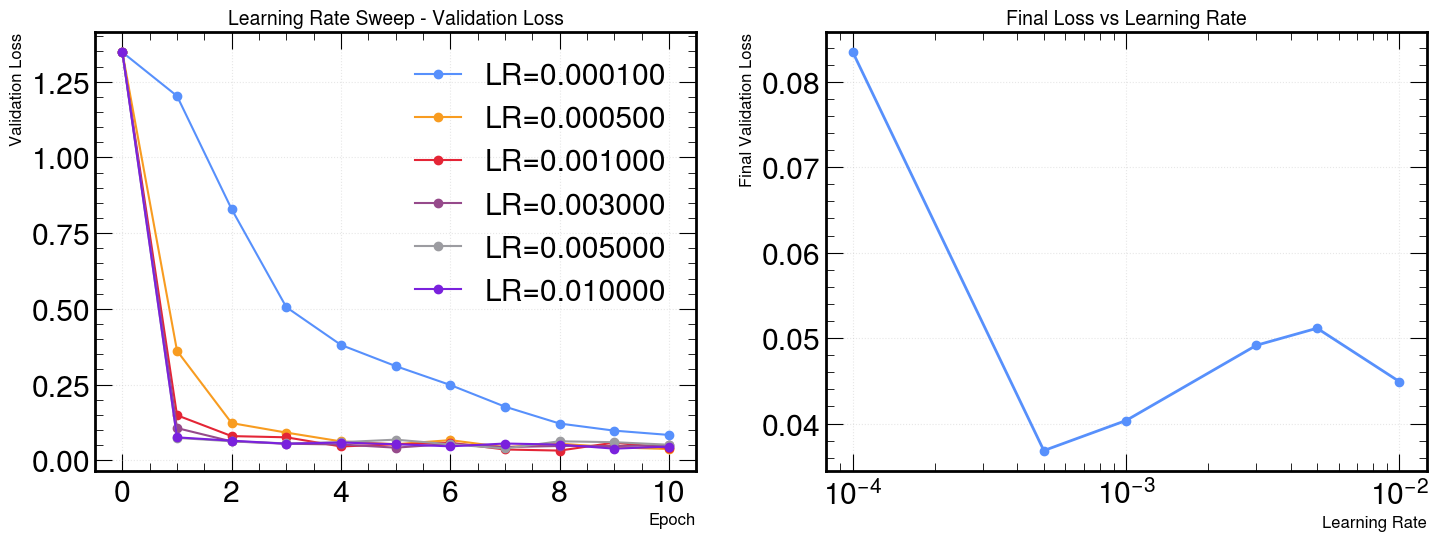

In [13]:
# ===== Plot LR Sweep Results =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot all learning curves
for result in lr_sweep_results:
    lr = result['lr']
    epochs = list(range(len(result['val_losses'])))
    ax1.plot(epochs, result['val_losses'], marker='o', label=f'LR={lr:.6f}')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Validation Loss', fontsize=12)
ax1.set_title('Learning Rate Sweep - Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot final loss vs LR
final_losses = [result['val_losses'][-1] for result in lr_sweep_results]
lrs = [result['lr'] for result in lr_sweep_results]
ax2.plot(lrs, final_losses, marker='o', linewidth=2)
ax2.set_xscale('log')
ax2.set_xlabel('Learning Rate', fontsize=12)
ax2.set_ylabel('Final Validation Loss', fontsize=12)
ax2.set_title('Final Loss vs Learning Rate', fontsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Find best LR
best_lr_idx = np.argmin(final_losses)
best_lr = lrs[best_lr_idx]
best_final_loss = final_losses[best_lr_idx]

print(f"\n{'='*70}")
print(f"BEST LEARNING RATE IDENTIFIED")
print(f"{'='*70}")
print(f"Best LR: {best_lr:.6f}")
print(f"Best final val loss: {best_final_loss:.4f}")
print(f"{'='*70}\n")


BEST LEARNING RATE IDENTIFIED
Best LR: 0.000500
Best final val loss: 0.0368



In [15]:
# ===== PHASE 2: Extended Training with Best LR =====
print("\n" + "="*70)
print("PHASE 2: Extended Training to Find Optimal Epochs")
print("="*70)

def train_extended(lr, num_epochs=100, patience=15):
    """
    Train for many epochs with early stopping
    """
    print(f"\nLearning Rate: {lr:.6f}")
    print(f"Max Epochs: {num_epochs}")
    print(f"Early Stopping Patience: {patience} epochs\n")
    
    # Set seed
    set_seed(42)
    
    # Initialize model
    model = HitGNN(
        input_node_dim=5, 
        edge_dim=5, 
        hidden_dim=10, 
        num_layers=6
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(75.0).to(device))
    
    # Track history
    history = {
        'train_loss': [],
        'val_loss': [],
        'epoch': []
    }
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch} - Train", leave=False):
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y.float().squeeze())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.inference_mode():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch} - Val", leave=False):
                batch = batch.to(device)
                out = model(batch)
                loss = loss_fn(out, batch.y.float().squeeze())
                val_loss += loss.item()
        val_loss /= len(val_loader)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch'].append(epoch)
        
        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_gnn_model.pt')
            status = "✓ NEW BEST"
        else:
            epochs_no_improve += 1
            status = f"({epochs_no_improve}/{patience})"
        
        print(f"Epoch {epoch:3d}: train={train_loss:.4f}, val={val_loss:.4f} | "
              f"best={best_val_loss:.4f} @ epoch {best_epoch} {status}")
        
        # Early stopping
        if epochs_no_improve >= patience:
            print(f"\n{'='*70}")
            print(f"Early stopping triggered after {epoch+1} epochs")
            print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
            print(f"{'='*70}\n")
            break
    
    return history, best_epoch, best_val_loss, model



PHASE 2: Extended Training to Find Optimal Epochs


In [16]:
history, best_epoch, best_val_loss, trained_model = train_extended(
    lr=best_lr, 
    num_epochs=100, 
    patience=15
)


Learning Rate: 0.000500
Max Epochs: 100
Early Stopping Patience: 15 epochs



Epoch   0: train=0.8533, val=0.3441 | best=0.3441 @ epoch 0 ✓ NEW BEST


Epoch   1: train=0.2072, val=0.1120 | best=0.1120 @ epoch 1 ✓ NEW BEST


Epoch   2: train=0.0845, val=0.0801 | best=0.0801 @ epoch 2 ✓ NEW BEST


Epoch   3: train=0.0726, val=0.0621 | best=0.0621 @ epoch 3 ✓ NEW BEST


...

Epoch  29: train=0.0304, val=0.0335 | best=0.0194 @ epoch 18 (11/15)


Epoch  30: train=0.0284, val=0.0329 | best=0.0194 @ epoch 18 (12/15)


Epoch  31: train=0.0278, val=0.0321 | best=0.0194 @ epoch 18 (13/15)


Epoch  32: train=0.0271, val=0.0425 | best=0.0194 @ epoch 18 (14/15)


Epoch  33: train=0.0295, val=0.0313 | best=0.0194 @ epoch 18 (15/15)

Early stopping triggered after 34 epochs
Best validation loss: 0.0194 at epoch 18



In [17]:
# Print summary
print(f"\n{'='*70}")
print(f"OPTIMAL HYPERPARAMETERS IDENTIFIED")
print(f"{'='*70}")
print(f"Best Learning Rate: {best_lr:.6f}")
print(f"Optimal Number of Epochs: {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Final Training Loss at Best Epoch: {history['train_loss'][best_epoch]:.4f}")
print(f"Overfitting Gap: {(best_val_loss - history['train_loss'][best_epoch]):.4f}")
print(f"{'='*70}\n")


OPTIMAL HYPERPARAMETERS IDENTIFIED
Best Learning Rate: 0.000500
Optimal Number of Epochs: 18
Best Validation Loss: 0.0194
Final Training Loss at Best Epoch: 0.0212
Overfitting Gap: -0.0018



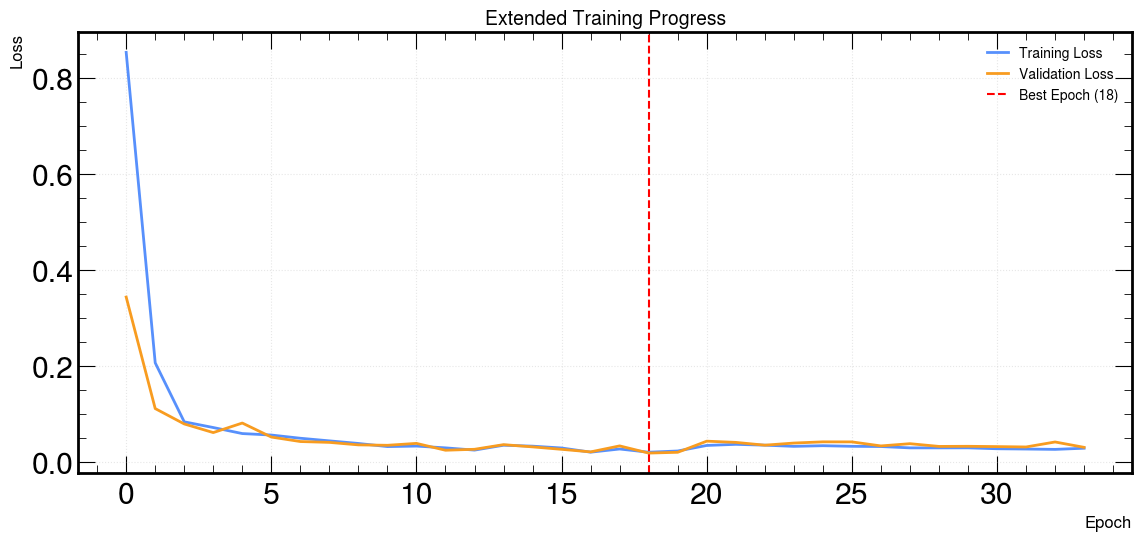

In [18]:
# ===== Plot Training History =====
fig, ax = plt.subplots(figsize=(12, 6))

epochs = history['epoch']
ax.plot(epochs, history['train_loss'], label='Training Loss', linewidth=2)
ax.plot(epochs, history['val_loss'], label='Validation Loss', linewidth=2)
ax.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Extended Training Progress', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


PHASE 3: Test Set Evaluation


Test set evaluation: 100%|██████████| 41/41 [00:00<00:00, 45.15it/s]



Test Loss: 0.0221

Generating ROC curve...


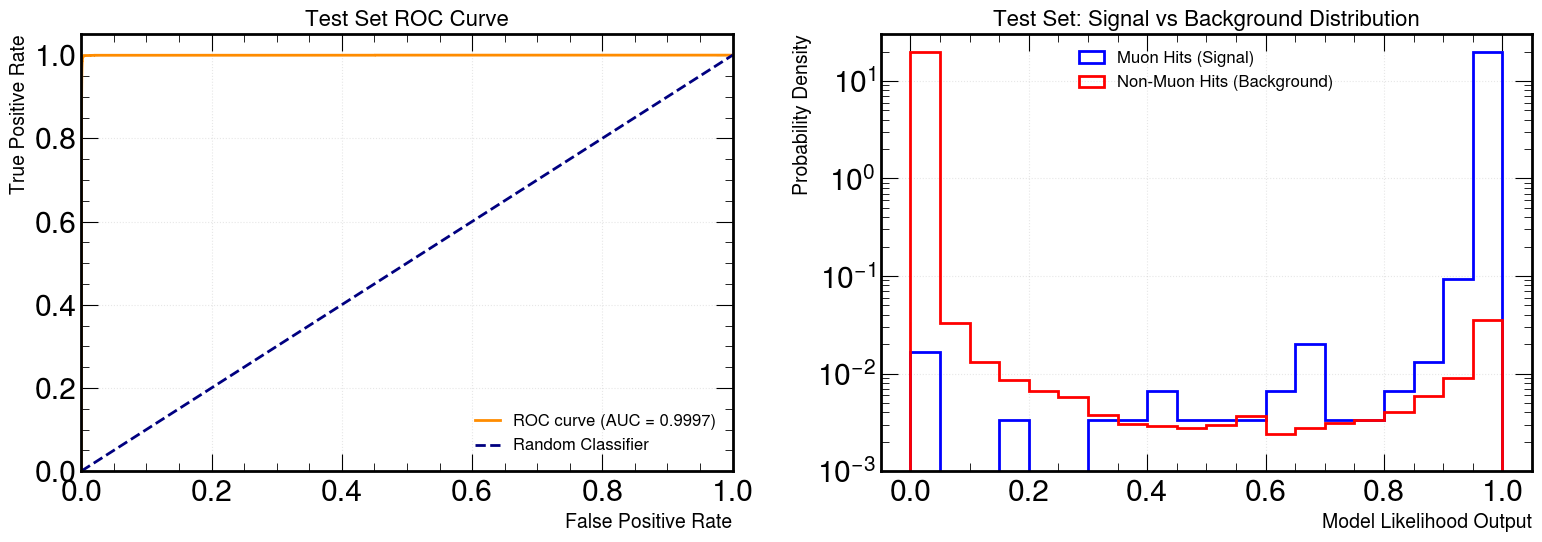

In [19]:
# ===== PHASE 3: Test Set Evaluation =====
print("\n" + "="*70)
print("PHASE 3: Test Set Evaluation")
print("="*70)

# Load best model
trained_model.load_state_dict(torch.load('best_gnn_model.pt'))
trained_model.eval()

all_probs = []
all_targets = []
loss_fn_test = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(75.0).to(device))

with torch.inference_mode():
    test_loss = 0
    for batch in tqdm(test_loader, desc='Test set evaluation'):
        batch = batch.to(device)
        out = trained_model(batch)
        test_loss += loss_fn_test(out, batch.y.float().squeeze()).item()
        
        # Collect predictions
        probs = nn.functional.sigmoid(out).cpu().numpy()
        targets = batch.y.squeeze().cpu().numpy()
        
        all_probs.append(probs)
        all_targets.append(targets)

test_loss /= len(test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

# Concatenate predictions
all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)

# ===== ROC Curve =====
print("\nGenerating ROC curve...")
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=14)
ax1.set_ylabel('True Positive Rate', fontsize=14)
ax1.set_title('Test Set ROC Curve', fontsize=16)
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(alpha=0.3)

# Likelihood Distribution
signal_probs = all_probs[all_targets == 1]
background_probs = all_probs[all_targets == 0]

bins = np.linspace(0, 1, 21)
ax2.hist(
    signal_probs, 
    bins=bins, 
    density=True, 
    label='Muon Hits (Signal)',
    histtype='step',
    color='blue',
    linewidth=2
)
ax2.hist(
    background_probs, 
    bins=bins, 
    density=True, 
    label='Non-Muon Hits (Background)',
    histtype='step',
    color='red',
    linewidth=2
)
ax2.set_yscale('log')
ax2.set_xlabel('Model Likelihood Output', fontsize=14)
ax2.set_ylabel('Probability Density', fontsize=14)
ax2.set_title('Test Set: Signal vs Background Distribution', fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)
ax2.set_ylim(1e-3, 3e1)

#if USE_CMS_STYLE:
#    mh.cms.label(ax=ax2, loc=0, label="Preliminary", data=False)

plt.tight_layout()
plt.show()

In [20]:
# ===== TPR/FPR Function =====
def compute_tpr_fpr(groundtruth, likelihood, cutoff):
    """Compute true positive rate and false positive rate for a given cutoff"""
    mask = groundtruth == 1
    n_muons = mask.sum()
    n_non_muons = (~mask).sum()
    
    tp = (likelihood[mask] >= cutoff).sum()
    tpr = tp / n_muons
    
    fp = (likelihood[~mask] >= cutoff).sum()
    fpr = fp / n_non_muons
    
    return float(tpr), float(fpr)

# Compute at cutoff = 0.5
tpr_50, fpr_50 = compute_tpr_fpr(all_targets, all_probs, 0.5)

In [21]:
# ===== Final Statistics =====
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(f"\nSignal Statistics:")
print(f"  Count:  {len(signal_probs):,}")
print(f"  Mean:   {signal_probs.mean():.4f}")
print(f"  Median: {np.median(signal_probs):.4f}")
print(f"\nBackground Statistics:")
print(f"  Count:  {len(background_probs):,}")
print(f"  Mean:   {background_probs.mean():.4f}")
print(f"  Median: {np.median(background_probs):.4f}")
print(f"\nModel Performance:")
print(f"  Test Set AUC: {roc_auc:.4f}")
print(f"  Test Set Loss: {test_loss:.4f}")
print(f"  TPR @ cutoff=0.5: {tpr_50:.4f}")
print(f"  FPR @ cutoff=0.5: {fpr_50:.4f}")
print(f"\nOptimal Hyperparameters:")
print(f"  Learning Rate: {best_lr:.6f}")
print(f"  Optimal Epochs: {best_epoch}")
print(f"  Best Val Loss: {best_val_loss:.4f}")
print(f"="*70)


FINAL RESULTS

Signal Statistics:
  Count:  6,033
  Mean:   0.9955
  Median: 0.9993

Background Statistics:
  Count:  453,042
  Mean:   0.0044
  Median: 0.0000

Model Performance:
  Test Set AUC: 0.9997
  Test Set Loss: 0.0221
  TPR @ cutoff=0.5: 0.9982
  FPR @ cutoff=0.5: 0.0036

Optimal Hyperparameters:
  Learning Rate: 0.000500
  Optimal Epochs: 18
  Best Val Loss: 0.0194



Reading HDF5 file...
Total entries: 264,114
Processed 50,000/264,114 events...
Processed 100,000/264,114 events...
Processed 150,000/264,114 events...
Processed 200,000/264,114 events...
Processed 250,000/264,114 events...

Extracted 286,852 pT values
Extracted 286,852 Eta values
Extracted 286,852 Phi values

✓ Plot saved: muon_pt_distribution.png


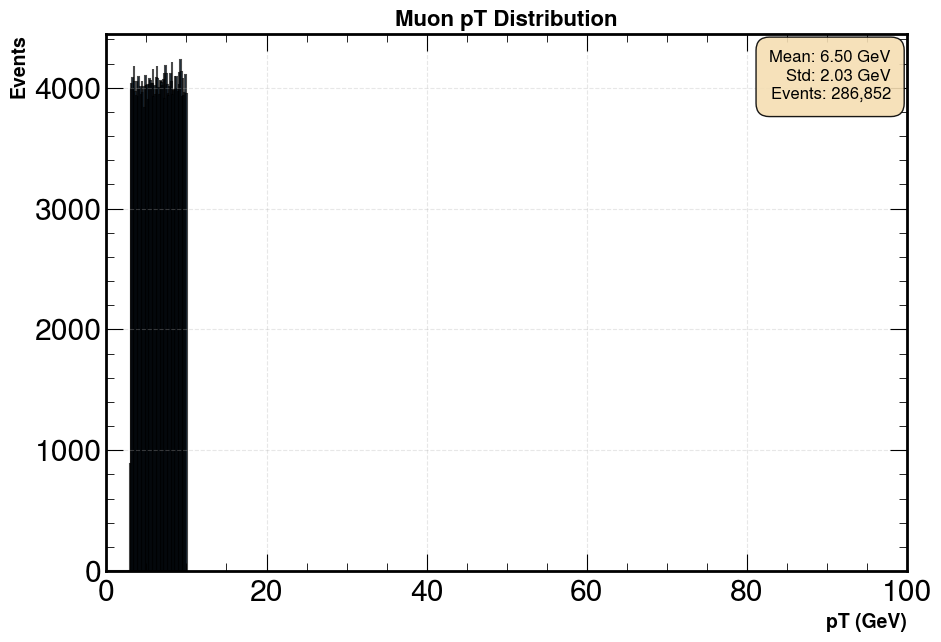

✓ Plot saved: muon_eta_distribution.png


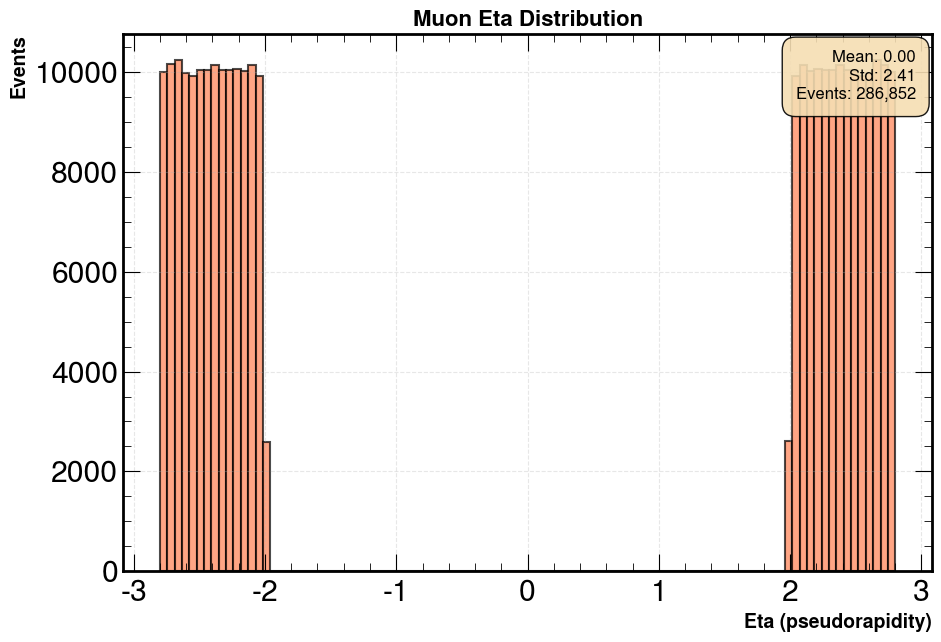

✓ Plot saved: muon_phi_distribution.png


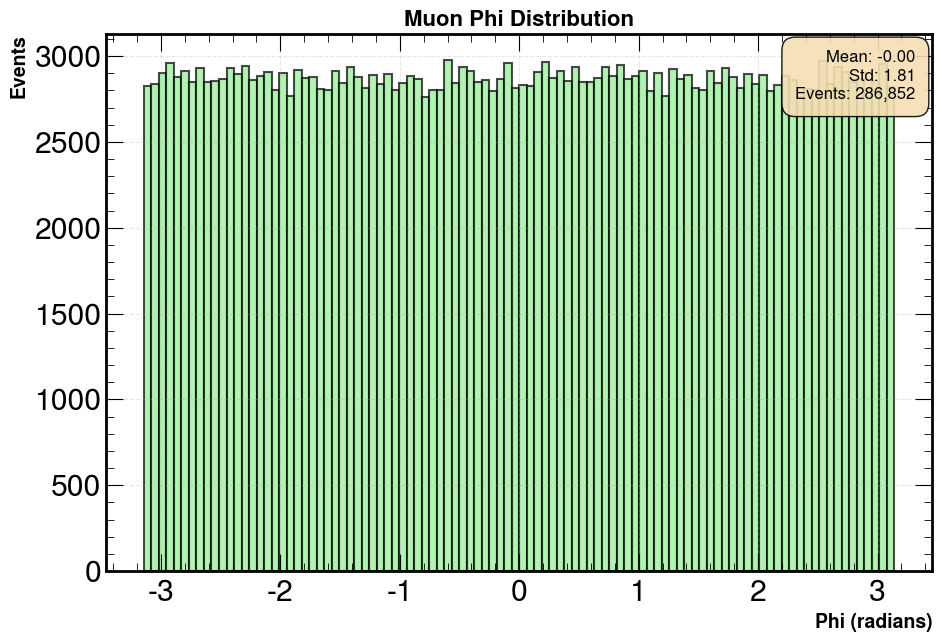


MUON KINEMATICS SUMMARY

📊 pT Distribution:
  Range: 0.154 - 10.010 GeV
  Mean:  6.504 GeV
  Std:   2.026 GeV
  Events: 286,852

📊 Eta Distribution:
  Range: -2.800 - 2.800
  Mean:  0.000
  Std:   2.412
  Events: 286,852

📊 Phi Distribution:
  Range: -3.142 - 3.142 rad
  Mean:  -0.003 rad
  Std:   1.814 rad
  Events: 286,852



In [22]:
# ============================================================================
# Plot 1: Muon pT Distribution (Separate)
# ============================================================================
import h5py
import numpy as np
import matplotlib.pyplot as plt
import mplhep as mh
import os

# Setup CMS style
mh.style.use("CMS")

hdf5_file = "/eos/user/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/data/merged_step4_rechit.h5"

print("\n" + "="*70)
print("Reading HDF5 file...")
print("="*70)

# Read data from HDF5
with h5py.File(hdf5_file, 'r') as f:
    chamber_data = f['chamber']
    n_events = len(chamber_data)
    print(f"Total entries: {n_events:,}")
    
    # Extract fields from structured array
    pt_list = []
    eta_list = []
    phi_list = []
    
    for i in range(n_events):
        entry = chamber_data[i]
        
        pt_entry = entry['pt']
        eta_entry = entry['eta']
        phi_entry = entry['phi']
        
        if hasattr(pt_entry, '__len__'):
            pt_list.extend(pt_entry)
            eta_list.extend(eta_entry)
            phi_list.extend(phi_entry)
        else:
            pt_list.append(float(pt_entry))
            eta_list.append(float(eta_entry))
            phi_list.append(float(phi_entry))
        
        if (i + 1) % 50000 == 0:
            print(f"Processed {i+1:,}/{n_events:,} events...")
    
    pt = np.array(pt_list, dtype=np.float32)
    eta = np.array(eta_list, dtype=np.float32)
    phi = np.array(phi_list, dtype=np.float32)

# Filter out zeros and invalid values
pt_valid = pt[pt > 0]
eta_valid = eta[eta != 0]
phi_valid = phi[phi != 0]

print(f"\nExtracted {len(pt_valid):,} pT values")
print(f"Extracted {len(eta_valid):,} Eta values")
print(f"Extracted {len(phi_valid):,} Phi values")

# ============================================================================
# PLOT 1: Muon pT Distribution
# ============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 7))

ax1.hist(pt_valid, bins=100, color='steelblue', edgecolor='black', alpha=0.7, linewidth=1.5)
ax1.set_xlabel('pT (GeV)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Events', fontsize=14, fontweight='bold')
ax1.set_title('Muon pT Distribution', fontsize=16, fontweight='bold')
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_xlim(0, 100)

# Add statistics box
stats_text = f'Mean: {pt_valid.mean():.2f} GeV\nStd: {pt_valid.std():.2f} GeV\nEvents: {len(pt_valid):,}'
ax1.text(0.98, 0.97, stats_text, transform=ax1.transAxes, fontsize=12, 
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, pad=0.8))

plt.tight_layout()
plt.savefig('muon_pt_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved: muon_pt_distribution.png")
plt.show()

# ============================================================================
# PLOT 2: Muon Eta Distribution
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(10, 7))

ax2.hist(eta_valid, bins=100, color='coral', edgecolor='black', alpha=0.7, linewidth=1.5)
ax2.set_xlabel('Eta (pseudorapidity)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Events', fontsize=14, fontweight='bold')
ax2.set_title('Muon Eta Distribution', fontsize=16, fontweight='bold')
ax2.grid(alpha=0.3, linestyle='--')

# Add statistics box
stats_text = f'Mean: {eta_valid.mean():.2f}\nStd: {eta_valid.std():.2f}\nEvents: {len(eta_valid):,}'
ax2.text(0.98, 0.97, stats_text, transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, pad=0.8))

plt.tight_layout()
plt.savefig('muon_eta_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: muon_eta_distribution.png")
plt.show()

# ============================================================================
# PLOT 3: Muon Phi Distribution
# ============================================================================
fig3, ax3 = plt.subplots(figsize=(10, 7))

ax3.hist(phi_valid, bins=100, color='lightgreen', edgecolor='black', alpha=0.7, linewidth=1.5)
ax3.set_xlabel('Phi (radians)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Events', fontsize=14, fontweight='bold')
ax3.set_title('Muon Phi Distribution', fontsize=16, fontweight='bold')
ax3.grid(alpha=0.3, linestyle='--')

# Add statistics box
stats_text = f'Mean: {phi_valid.mean():.2f}\nStd: {phi_valid.std():.2f}\nEvents: {len(phi_valid):,}'
ax3.text(0.98, 0.97, stats_text, transform=ax3.transAxes, fontsize=12,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, pad=0.8))

plt.tight_layout()
plt.savefig('muon_phi_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved: muon_phi_distribution.png")
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "="*70)
print("MUON KINEMATICS SUMMARY")
print("="*70)

print(f"\n📊 pT Distribution:")
print(f"  Range: {pt_valid.min():.3f} - {pt_valid.max():.3f} GeV")
print(f"  Mean:  {pt_valid.mean():.3f} GeV")
print(f"  Std:   {pt_valid.std():.3f} GeV")
print(f"  Events: {len(pt_valid):,}")

print(f"\n📊 Eta Distribution:")
print(f"  Range: {eta_valid.min():.3f} - {eta_valid.max():.3f}")
print(f"  Mean:  {eta_valid.mean():.3f}")
print(f"  Std:   {eta_valid.std():.3f}")
print(f"  Events: {len(eta_valid):,}")

print(f"\n📊 Phi Distribution:")
print(f"  Range: {phi_valid.min():.3f} - {phi_valid.max():.3f} rad")
print(f"  Mean:  {phi_valid.mean():.3f} rad")
print(f"  Std:   {phi_valid.std():.3f} rad")
print(f"  Events: {len(phi_valid):,}")

print("\n" + "="*70)

                    TOTAL TIME FOR ENTIRE DATASET
               (All 35,430 Events - Cumulative Times)

[CONFIG]
  HDF5 file: /eos/user/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/data/merged_step4_rechit.h5
  Device: cuda
  Measuring TOTAL time for entire dataset

[INFO] Total events: 264,114
[INFO] Processing entire dataset...

[WARM-UP] Initializing GPU...
✓ Warm-up complete

PROCESSING ENTIRE DATASET



Processing all events: 100%|██████████| 264114/264114 [19:58<00:00, 220.44it/s]



✓ Processing complete!

TOTAL TIME FOR ENTIRE DATASET
(264,114 events)

1️⃣  GRAPH CONSTRUCTION TIME (Entire Dataset)

  Total time:        281.687 seconds
  Total time:        4.695 minutes
  Total time:        0.078 hours
  Average per graph: 1.067 ms

2️⃣  MODEL PREDICTION TIME (Entire Dataset)

  Total time:        810.304 seconds
  Total time:        13.505 minutes
  Total time:        0.225 hours
  Average per graph: 3.068 ms

3️⃣  TOTAL INFERENCE TIME (Entire Dataset)

  Total time:        1097.411 seconds
  Total time:        18.290 minutes
  Total time:        0.305 hours
  Average per graph: 4.155 ms

📊 TIME BREAKDOWN

  Component                      Time (sec)      Time (min)      Percentage  
  ---------------------------------------------------------------------------
  Graph Construction                   281.687           4.695         25.7%
  Model Prediction                     810.304          13.505         73.8%
  Overhead (sync, etc.)                  5.420      

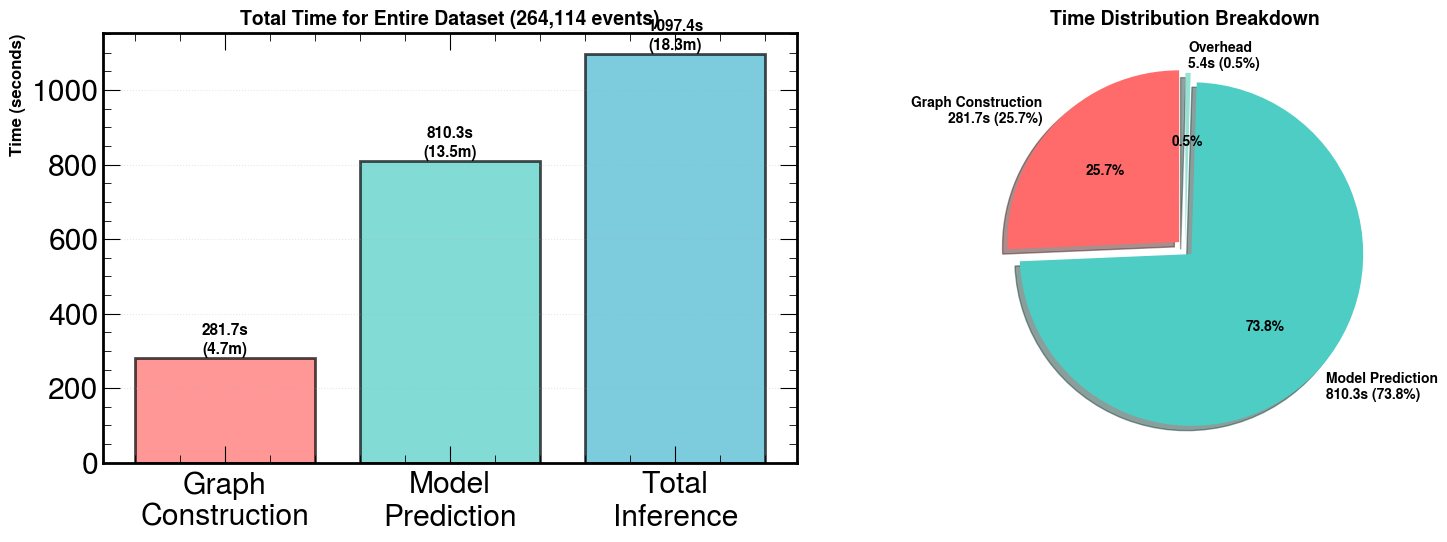


💾 SAVING RESULTS
✓ Summary saved to 'total_dataset_time_summary.csv'

✅ FINAL SUMMARY

TOTAL TIME FOR ENTIRE DATASET (264,114 events):

1️⃣  GRAPH CONSTRUCTION:
    281.69 seconds = 4.69 minutes = 0.078 hours
    (25.7% of total time)

2️⃣  MODEL PREDICTION:
    810.30 seconds = 13.51 minutes = 0.225 hours
    (73.8% of total time)

3️⃣  TOTAL INFERENCE TIME:
    1097.41 seconds = 18.29 minutes = 0.305 hours

THROUGHPUT:
    240.7 graphs/second
    14440.2 graphs/minute
    866412 graphs/hour

PROCESSED:
    24,583,175 total hits
    53,883,926 total edges created

✅ COMPLETE

📊 Summary Table:



,Metric,Value
0,Total Events,2.641140e+05
1,Graph Construction Time (seconds),2.816868e+02
2,Graph Construction Time (minutes),4.694780e+00
3,Model Prediction Time (seconds),8.103045e+02
4,Model Prediction Time (minutes),1.350507e+01
5,Total Inference Time (seconds),1.097411e+03
6,Total Inference Time (minutes),1.829018e+01
7,Graph Construction Percentage,2.566831e+01
8,Model Prediction Percentage,7.383784e+01
9,Overhead Percentage,4.938534e-01


In [23]:
# ===== TOTAL TIME FOR ENTIRE DATASET =====
print("="*80)
print(" "*20 + "TOTAL TIME FOR ENTIRE DATASET")
print(" "*15 + "(All 35,430 Events - Cumulative Times)")
print("="*80)

import torch
import h5py
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch_geometric.data import Data

# ===== Configuration =====
H5_PATH = '/eos/user/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/data/merged_step4_rechit.h5'
D_STRIP_MAX = 10
D_IETA_MAX = 2
D_BX_MAX = 1

print(f"\n[CONFIG]")
print(f"  HDF5 file: {H5_PATH}")
print(f"  Device: {device}")
print(f"  Measuring TOTAL time for entire dataset\n")

# Check GPU
if device.type != 'cuda':
    print("⚠️  WARNING: GPU not detected. This code requires CUDA.")
    raise RuntimeError("GPU required")

# ===== Graph Construction Function =====
def build_graph_on_gpu(chamber_data, device, d_strip_max, d_ieta_max, d_bx_max):
    """Build graph from raw hits on GPU"""
    x = torch.stack([
        torch.tensor(chamber_data['bx'], dtype=torch.float32, device=device),
        torch.tensor(chamber_data['ieta'], dtype=torch.float32, device=device),
        torch.tensor(chamber_data['layer'], dtype=torch.float32, device=device),
        torch.tensor(chamber_data['strip'], dtype=torch.float32, device=device),
        torch.tensor(chamber_data['cls'], dtype=torch.float32, device=device)
    ], dim=1)
    
    y = torch.tensor(chamber_data['label'], device=device).unsqueeze(1)
    num_nodes = x.size(0)
    
    adj_idx = torch.combinations(torch.arange(num_nodes, device=device), r=2)
    i, j = adj_idx[:, 0], adj_idx[:, 1]
    diffs = torch.abs(x[i] - x[j])
    
    mask = (diffs[:, 3] <= d_strip_max) & \
           (diffs[:, 1] <= d_ieta_max) & \
           (diffs[:, 0] <= d_bx_max) & \
           (x[i, 2] != x[j, 2])
    
    edge_attr = diffs[mask].t().contiguous().permute(1, 0)
    edge_index = adj_idx[mask].t().contiguous()
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    edge_attr = torch.cat([edge_attr, edge_attr], dim=0)
    
    return Data(x=x, edge_index=edge_index, y=y, edge_attr=edge_attr)

# ===== Get Dataset Info =====
with h5py.File(H5_PATH, 'r') as f:
    total_events = len(f['chamber'])

print(f"[INFO] Total events: {total_events:,}")
print(f"[INFO] Processing entire dataset...\n")

# ===== Warm-up =====
print("[WARM-UP] Initializing GPU...")
with h5py.File(H5_PATH, 'r') as f:
    warmup_data = f['chamber'][0]
    warmup_graph = build_graph_on_gpu(warmup_data, device, D_STRIP_MAX, D_IETA_MAX, D_BX_MAX)
    with torch.inference_mode():
        _ = trained_model(warmup_graph)
    torch.cuda.synchronize()
print("✓ Warm-up complete\n")

# ===== Initialize Accumulators =====
total_graph_construction_time = 0.0
total_prediction_time = 0.0
total_inference_time = 0.0

total_hits = 0
total_edges = 0

# ===== MEASURE ENTIRE DATASET =====
print("="*80)
print("PROCESSING ENTIRE DATASET")
print("="*80)
print()

with h5py.File(H5_PATH, 'r') as f:
    chambers = f['chamber']
    
    with torch.inference_mode():
        for idx in tqdm(range(total_events), desc="Processing all events"):
            chamber_data = chambers[idx]
            
            # === START TOTAL TIME ===
            total_start = time.perf_counter()
            
            # === 1. GRAPH CONSTRUCTION ===
            graph_start = time.perf_counter()
            graph = build_graph_on_gpu(chamber_data, device, D_STRIP_MAX, D_IETA_MAX, D_BX_MAX)
            torch.cuda.synchronize()
            graph_end = time.perf_counter()
            
            # Accumulate graph construction time
            total_graph_construction_time += (graph_end - graph_start)
            
            # === 2. MODEL PREDICTION ===
            prediction_start = time.perf_counter()
            output = trained_model(graph)
            torch.cuda.synchronize()
            prediction_end = time.perf_counter()
            
            # Accumulate prediction time
            total_prediction_time += (prediction_end - prediction_start)
            
            # === END TOTAL TIME ===
            total_end = time.perf_counter()
            
            # Accumulate total time
            total_inference_time += (total_end - total_start)
            
            # Accumulate graph statistics
            total_hits += graph.num_nodes
            total_edges += graph.num_edges

print("\n✓ Processing complete!\n")

# ===== RESULTS =====
print("="*80)
print("TOTAL TIME FOR ENTIRE DATASET")
print(f"({total_events:,} events)")
print("="*80)

print("\n" + "="*80)
print("1️⃣  GRAPH CONSTRUCTION TIME (Entire Dataset)")
print("="*80)
print(f"\n  Total time:        {total_graph_construction_time:.3f} seconds")
print(f"  Total time:        {total_graph_construction_time/60:.3f} minutes")
print(f"  Total time:        {total_graph_construction_time/3600:.3f} hours")
print(f"  Average per graph: {total_graph_construction_time*1000/total_events:.3f} ms")

print("\n" + "="*80)
print("2️⃣  MODEL PREDICTION TIME (Entire Dataset)")
print("="*80)
print(f"\n  Total time:        {total_prediction_time:.3f} seconds")
print(f"  Total time:        {total_prediction_time/60:.3f} minutes")
print(f"  Total time:        {total_prediction_time/3600:.3f} hours")
print(f"  Average per graph: {total_prediction_time*1000/total_events:.3f} ms")

print("\n" + "="*80)
print("3️⃣  TOTAL INFERENCE TIME (Entire Dataset)")
print("="*80)
print(f"\n  Total time:        {total_inference_time:.3f} seconds")
print(f"  Total time:        {total_inference_time/60:.3f} minutes")
print(f"  Total time:        {total_inference_time/3600:.3f} hours")
print(f"  Average per graph: {total_inference_time*1000/total_events:.3f} ms")

# ===== BREAKDOWN =====
print("\n" + "="*80)
print("📊 TIME BREAKDOWN")
print("="*80)

graph_percent = (total_graph_construction_time / total_inference_time) * 100
prediction_percent = (total_prediction_time / total_inference_time) * 100
overhead_time = total_inference_time - (total_graph_construction_time + total_prediction_time)
overhead_percent = (overhead_time / total_inference_time) * 100

print(f"\n  {'Component':<30} {'Time (sec)':<15} {'Time (min)':<15} {'Percentage':<12}")
print(f"  {'-'*75}")
print(f"  {'Graph Construction':<30} {total_graph_construction_time:>13.3f}   {total_graph_construction_time/60:>13.3f}   {graph_percent:>10.1f}%")
print(f"  {'Model Prediction':<30} {total_prediction_time:>13.3f}   {total_prediction_time/60:>13.3f}   {prediction_percent:>10.1f}%")
print(f"  {'Overhead (sync, etc.)':<30} {overhead_time:>13.3f}   {overhead_time/60:>13.3f}   {overhead_percent:>10.1f}%")
print(f"  {'-'*75}")
print(f"  {'TOTAL':<30} {total_inference_time:>13.3f}   {total_inference_time/60:>13.3f}   {'100.0%':>10}")

# ===== THROUGHPUT =====
print("\n" + "="*80)
print("📈 THROUGHPUT")
print("="*80)

throughput_graphs_per_sec = total_events / total_inference_time
throughput_graphs_per_min = throughput_graphs_per_sec * 60
throughput_graphs_per_hour = throughput_graphs_per_sec * 3600

print(f"\n  Graphs per second:     {throughput_graphs_per_sec:.1f}")
print(f"  Graphs per minute:     {throughput_graphs_per_min:.1f}")
print(f"  Graphs per hour:       {throughput_graphs_per_hour:.1f}")

# ===== GRAPH STATISTICS =====
print("\n" + "="*80)
print("📊 GRAPH STATISTICS (Entire Dataset)")
print("="*80)

avg_hits = total_hits / total_events
avg_edges = total_edges / total_events
avg_possible_edges = avg_hits * (avg_hits - 1)
edge_density = (avg_edges / avg_possible_edges * 100) if avg_possible_edges > 0 else 0

print(f"\n  Total hits processed:      {total_hits:,}")
print(f"  Total edges created:       {total_edges:,}")
print(f"  Average hits per event:    {avg_hits:.1f}")
print(f"  Average edges per graph:   {avg_edges:.1f}")
print(f"  Average edge density:      {edge_density:.1f}%")

# ===== VISUALIZATION =====
print("\n" + "="*80)
print("📊 GENERATING VISUALIZATION")
print("="*80)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart - Total times
ax1 = axes[0]
components = ['Graph\nConstruction', 'Model\nPrediction', 'Total\nInference']
times_seconds = [total_graph_construction_time, total_prediction_time, total_inference_time]
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax1.bar(components, times_seconds, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Time (seconds)', fontsize=12, weight='bold')
ax1.set_title(f'Total Time for Entire Dataset ({total_events:,} events)', fontsize=14, weight='bold')
ax1.grid(alpha=0.3, axis='y')

# Add value labels
for bar, time_val in zip(bars, times_seconds):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{time_val:.1f}s\n({time_val/60:.1f}m)',
            ha='center', va='bottom', fontsize=11, weight='bold')

# Plot 2: Pie chart - Breakdown
ax2 = axes[1]
sizes = [total_graph_construction_time, total_prediction_time, overhead_time]
labels_pie = [f'Graph Construction\n{total_graph_construction_time:.1f}s ({graph_percent:.1f}%)',
              f'Model Prediction\n{total_prediction_time:.1f}s ({prediction_percent:.1f}%)',
              f'Overhead\n{overhead_time:.1f}s ({overhead_percent:.1f}%)']
colors_pie = ['#FF6B6B', '#4ECDC4', '#95E1D3']
explode = (0.05, 0.05, 0.02)

ax2.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax2.set_title('Time Distribution Breakdown', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig('total_dataset_time.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'total_dataset_time.png'")
plt.show()

# ===== SAVE RESULTS =====
print("\n" + "="*80)
print("💾 SAVING RESULTS")
print("="*80)

# Summary table
summary = {
    'Metric': [
        'Total Events',
        'Graph Construction Time (seconds)',
        'Graph Construction Time (minutes)',
        'Model Prediction Time (seconds)',
        'Model Prediction Time (minutes)',
        'Total Inference Time (seconds)',
        'Total Inference Time (minutes)',
        'Graph Construction Percentage',
        'Model Prediction Percentage',
        'Overhead Percentage',
        'Throughput (graphs/second)',
        'Throughput (graphs/minute)',
        'Total Hits Processed',
        'Total Edges Created',
        'Average Hits per Event',
        'Average Edges per Graph',
        'Average Edge Density (%)'
    ],
    'Value': [
        total_events,
        total_graph_construction_time,
        total_graph_construction_time / 60,
        total_prediction_time,
        total_prediction_time / 60,
        total_inference_time,
        total_inference_time / 60,
        graph_percent,
        prediction_percent,
        overhead_percent,
        throughput_graphs_per_sec,
        throughput_graphs_per_min,
        total_hits,
        total_edges,
        avg_hits,
        avg_edges,
        edge_density
    ]
}

df_summary = pd.DataFrame(summary)
df_summary.to_csv('total_dataset_time_summary.csv', index=False)
print("✓ Summary saved to 'total_dataset_time_summary.csv'")

# ===== FINAL SUMMARY =====
print("\n" + "="*80)
print("✅ FINAL SUMMARY")
print("="*80)

print(f"""
TOTAL TIME FOR ENTIRE DATASET ({total_events:,} events):

1️⃣  GRAPH CONSTRUCTION:
    {total_graph_construction_time:.2f} seconds = {total_graph_construction_time/60:.2f} minutes = {total_graph_construction_time/3600:.3f} hours
    ({graph_percent:.1f}% of total time)

2️⃣  MODEL PREDICTION:
    {total_prediction_time:.2f} seconds = {total_prediction_time/60:.2f} minutes = {total_prediction_time/3600:.3f} hours
    ({prediction_percent:.1f}% of total time)

3️⃣  TOTAL INFERENCE TIME:
    {total_inference_time:.2f} seconds = {total_inference_time/60:.2f} minutes = {total_inference_time/3600:.3f} hours

THROUGHPUT:
    {throughput_graphs_per_sec:.1f} graphs/second
    {throughput_graphs_per_min:.1f} graphs/minute
    {throughput_graphs_per_hour:.0f} graphs/hour

PROCESSED:
    {total_hits:,} total hits
    {total_edges:,} total edges created
""")

print("="*80)
print("✅ COMPLETE")
print("="*80)

# Display summary
print("\n📊 Summary Table:\n")
display(df_summary)

In [ ]:
# ===== Device Setup =====
device = torch.device('cuda' if torch.cuda.is_available() else 
                     'mps' if torch.mps.is_available() else 'cpu')
print(f"Using device: {device}")